# Daily model-specific anchor GLS residual raw spatial semivariogram diagnostic, 2022-2025 July

This notebook implements diagnostic 2: each model gets its own GLS detrending based on its fitted covariance parameters.

For each day and model, GLS beta is estimated from a regular spatial anchor subset using `ColumnAmountO3 ~ hour fixed effects + latitude + longitude` and the model-implied space-time covariance. The fitted mean is then applied to the full grid before computing residual semivariograms. This is an anchor-subset feasible GLS diagnostic, not a full 145k-by-145k exact GLS.

Each daily figure has one row per model and two columns for latitude/longitude directions. The black curve is the model-specific daily residual semivariogram; the colored curve is that same model's fitted t=0 semivariogram.


In [1]:
import os
import pickle
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.linalg import cho_factor, cho_solve
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120

PROJECT_ROOT = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
DATA_ROOT = Path('/Users/joonwonlee/Documents/GEMS_DATA')

YEARS = [2022, 2023, 2024, 2025]
MONTH = 7
COMMON_DAYS = list(range(1, 29))
LAT_RANGE = [-3.0, 2.0]
LON_RANGE = [121.0, 131.0]
SMOOTH = 0.5  # fitted model convention used in these estimates; exponential Matern
MEAN_MODEL = 'model_specific_anchor_gls_hour_dummy_plus_lat_lon'
NORMALIZE_EMPIRICAL = False
Y_LIMIT = (0, 20)
ANCHOR_LAT_STRIDE = 10
ANCHOR_LON_STRIDE = 10
GLS_JITTER = 1e-8
MODEL_ORDER = ['Vecchia_mm20', 'Debiased_Whittle', 'Corridor_4x4_lag643']

# Positive univariate lag grid; zero spatial lag is deliberately excluded.
LAT_LAGS = np.concatenate([[0.044, 0.132], np.arange(0.176, 2.3, 0.044 * 5)])
LON_LAGS = np.concatenate([[0.063, 0.126], np.arange(0.18, 2.0, 0.063 * 3)])
LAT_LAGS = np.round(LAT_LAGS, 3)
LON_LAGS = np.round(LON_LAGS, 3)

ESTIMATE_FILES = {
    'Vecchia_mm20': PROJECT_ROOT / 'outputs/day/july_22_23_24_25/real_vecc_july_22_23_24_25_mm20.csv',
    'Debiased_Whittle': PROJECT_ROOT / 'outputs/day/july_22_23_24_25/real_dw_july_22_23_24_25.csv',
    'Corridor_4x4_lag643': PROJECT_ROOT / 'outputs/day/july_22_23_24_25/real_july_corridor_width_4x4_lag643_all_fits.csv',
}

OUTPUT_DIR = PROJECT_ROOT / 'plots/directional_semivariograms/daily_spatial_semivariograms_residual_gls_raw_three_model_2022_2025_052526'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Output directory: {OUTPUT_DIR}')
print(f'Mean model: {MEAN_MODEL}')
print(f'Normalize empirical residual semivariogram: {NORMALIZE_EMPIRICAL}')
print(f'Anchor strides: lat={ANCHOR_LAT_STRIDE}, lon={ANCHOR_LON_STRIDE}')
print('lat lags:', LAT_LAGS)
print('lon lags:', LON_LAGS)


Output directory: /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_spatial_semivariograms_residual_gls_raw_three_model_2022_2025_052526
Mean model: model_specific_anchor_gls_hour_dummy_plus_lat_lon
Normalize empirical residual semivariogram: False
Anchor strides: lat=10, lon=10
lat lags: [0.044 0.132 0.176 0.396 0.616 0.836 1.056 1.276 1.496 1.716 1.936 2.156]
lon lags: [0.063 0.126 0.18  0.369 0.558 0.747 0.936 1.125 1.314 1.503 1.692 1.881]


In [2]:
def parse_day_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'day' in df.columns:
        parsed = df['day'].astype(str).str.extract(r'(?P<year>\d{4})-(?P<month>\d{1,2})-(?P<day_num>\d{1,2})')
        for col in ['year', 'month', 'day_num']:
            if col not in df.columns or df[col].isna().all():
                df[col] = pd.to_numeric(parsed[col], errors='coerce').astype('Int64')
    elif {'year', 'month', 'day_idx'}.issubset(df.columns):
        df['day_num'] = pd.to_numeric(df['day_idx'], errors='coerce').astype('Int64') + 1
    return df


def load_one_estimate_file(model_name: str, path: Path) -> pd.DataFrame:
    raw = pd.read_csv(path)
    raw = parse_day_columns(raw)
    if 'status' in raw.columns:
        raw = raw.loc[raw['status'].astype(str).str.lower().eq('ok')].copy()

    if {'est_sigmasq', 'est_range_lat', 'est_range_lon', 'est_range_time', 'est_advec_lat', 'est_advec_lon', 'est_nugget'}.issubset(raw.columns):
        mapped = pd.DataFrame({
            'model': model_name,
            'year': raw['year'],
            'month': raw['month'],
            'day_num': raw['day_num'],
            'day': raw['day'],
            'cov_name': raw.get('spec_name', model_name),
            'sigma': raw['est_sigmasq'],
            'range_lat': raw['est_range_lat'],
            'range_lon': raw['est_range_lon'],
            'range_time': raw['est_range_time'],
            'advec_lat': raw['est_advec_lat'],
            'advec_lon': raw['est_advec_lon'],
            'nugget': raw['est_nugget'],
            'loss': raw.get('loss', np.nan),
            'time': raw.get('total_s', raw.get('time', np.nan)),
        })
    else:
        mapped = pd.DataFrame({
            'model': model_name,
            'year': raw['year'],
            'month': raw['month'],
            'day_num': raw['day_num'],
            'day': raw['day'],
            'cov_name': raw.get('cov_name', model_name),
            'sigma': raw['sigma'],
            'range_lat': raw['range_lat'],
            'range_lon': raw['range_lon'],
            'range_time': raw['range_time'],
            'advec_lat': raw['advec_lat'],
            'advec_lon': raw['advec_lon'],
            'nugget': raw['nugget'],
            'loss': raw.get('loss', np.nan),
            'time': raw.get('time', np.nan),
        })

    numeric_cols = ['year', 'month', 'day_num', 'sigma', 'range_lat', 'range_lon', 'range_time', 'advec_lat', 'advec_lon', 'nugget', 'loss', 'time']
    for col in numeric_cols:
        mapped[col] = pd.to_numeric(mapped[col], errors='coerce')
    return mapped


def load_all_estimates(files: Dict[str, Path]) -> pd.DataFrame:
    frames = [load_one_estimate_file(name, path) for name, path in files.items()]
    out = pd.concat(frames, ignore_index=True)
    out = out.loc[out['year'].isin(YEARS) & out['month'].eq(MONTH) & out['day_num'].isin(COMMON_DAYS)].copy()
    out = out.sort_values(['year', 'day_num', 'model']).reset_index(drop=True)
    return out


estimates = load_all_estimates(ESTIMATE_FILES)
param_cols = ['year', 'model', 'day', 'sigma', 'range_lat', 'range_lon', 'range_time', 'advec_lat', 'advec_lon', 'nugget', 'loss', 'time']
param_table = estimates[param_cols].round(4)
param_csv = OUTPUT_DIR / 'three_model_parameter_estimates_2022_2025_07.csv'
param_table.to_csv(param_csv, index=False, float_format='%.4f')
print(f'Saved {param_csv}')
display(param_table.head(12))


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_spatial_semivariograms_residual_gls_raw_three_model_2022_2025_052526/three_model_parameter_estimates_2022_2025_07.csv


,year,model,day,sigma,range_lat,range_lon,range_time,advec_lat,advec_lon,nugget,loss,time
0,2022,Corridor_4x4_lag643,2022-07-01,3.9851,0.1194,0.1515,1.1154,0.0038,-0.0223,2.2072,1.2093,35.4315
1,2022,Debiased_Whittle,2022-07-1,3.5972,0.1418,0.2201,1.2601,-0.0156,0.0799,2.4864,115551.0880,111.7636
2,2022,Vecchia_mm20,2022-07-1,3.4937,0.1703,0.2118,1.6525,-0.0009,-0.0269,2.6723,1.2591,54.4569
3,2022,Corridor_4x4_lag643,2022-07-02,7.0359,0.1715,0.1787,1.0242,0.0075,-0.2795,1.8939,1.2553,24.8630
4,2022,Debiased_Whittle,2022-07-2,6.4137,0.1200,0.1311,0.8784,0.0299,-0.2897,1.4776,246956.5280,94.1755
5,2022,Vecchia_mm20,2022-07-2,7.8296,0.3299,0.3572,1.6104,0.0263,-0.1932,2.6110,1.3469,39.9762
6,2022,Corridor_4x4_lag643,2022-07-03,8.8221,0.1898,0.2358,1.0405,0.0182,-0.1128,1.5376,1.2257,21.7607
7,2022,Debiased_Whittle,2022-07-3,5.9562,0.1507,0.1610,0.8402,0.0092,-0.0588,1.0284,-79128.9280,75.2054
8,2022,Vecchia_mm20,2022-07-3,10.2319,0.3491,0.5161,1.8609,0.0359,-0.1294,2.2946,1.3337,33.3842
9,2022,Corridor_4x4_lag643,2022-07-04,7.6722,0.1842,0.1821,1.2079,0.0455,-0.1758,2.1201,1.2960,27.8050


In [3]:
DATA_CACHE = {}
GRID_CACHE = {}
GLS_CACHE = {}


def load_year_raw_map(year: int) -> Dict[str, pd.DataFrame]:
    if year not in DATA_CACHE:
        path = DATA_ROOT / f'pickle_{year}' / f'tco_grid_{str(year)[2:]}_{MONTH:02d}.pkl'
        with open(path, 'rb') as f:
            DATA_CACHE[year] = pickle.load(f)
        print(f'Loaded {len(DATA_CACHE[year])} hourly maps for {year}-{MONTH:02d}')
    return DATA_CACHE[year]


def build_grid_meta(year: int):
    if year in GRID_CACHE:
        return GRID_CACHE[year]
    raw = load_year_raw_map(year)
    first_key = sorted(raw)[0]
    df = raw[first_key].copy()
    mask = (
        df['Latitude'].between(LAT_RANGE[0], LAT_RANGE[1])
        & df['Longitude'].between(LON_RANGE[0], LON_RANGE[1])
    ).to_numpy()
    sub = df.loc[mask].copy()
    lats = np.sort(sub['Latitude'].round(6).unique())
    lons = np.sort(sub['Longitude'].round(6).unique())
    lat_to_i = {float(v): i for i, v in enumerate(lats)}
    lon_to_j = {float(v): j for j, v in enumerate(lons)}
    cell_lat = pd.to_numeric(sub['Latitude'], errors='coerce').to_numpy(dtype=float)
    cell_lon = pd.to_numeric(sub['Longitude'], errors='coerce').to_numpy(dtype=float)
    lat_idx = sub['Latitude'].round(6).map(lat_to_i).to_numpy(dtype=int)
    lon_idx = sub['Longitude'].round(6).map(lon_to_j).to_numpy(dtype=int)
    anchor_mask = (lat_idx % ANCHOR_LAT_STRIDE == 0) & (lon_idx % ANCHOR_LON_STRIDE == 0)
    meta = {
        'mask': mask,
        'lats': lats,
        'lons': lons,
        'cell_lat': cell_lat,
        'cell_lon': cell_lon,
        'lat_idx': lat_idx,
        'lon_idx': lon_idx,
        'anchor_mask': anchor_mask,
        'lat_step': float(np.nanmedian(np.diff(lats))),
        'lon_step': float(np.nanmedian(np.diff(lons))),
    }
    GRID_CACHE[year] = meta
    print(
        f'{year}: grid shape={len(lats)}x{len(lons)}, '
        f'lat_step={meta["lat_step"]:.4f}, lon_step={meta["lon_step"]:.4f}, '
        f'anchors/hour={int(anchor_mask.sum())}'
    )
    return meta


def keys_for_day(raw_map: Dict[str, pd.DataFrame], day: int):
    token = f'day{int(day):02d}'
    return [k for k in sorted(raw_map) if token in k]


def model_covariance_matrix(lat: np.ndarray, lon: np.ndarray, hour: np.ndarray, est: pd.Series) -> np.ndarray:
    sigmasq = float(est['sigma'])
    nugget = float(est['nugget'])
    range_lat = max(float(est['range_lat']), 1e-12)
    range_lon = max(float(est['range_lon']), 1e-12)
    range_time = max(float(est['range_time']), 1e-12)
    advec_lat = float(est['advec_lat'])
    advec_lon = float(est['advec_lon'])

    lat_diff = lat[None, :] - lat[:, None]
    lon_diff = lon[None, :] - lon[:, None]
    hour_diff = hour[None, :] - hour[:, None]
    distance = np.sqrt(
        ((lat_diff - advec_lat * hour_diff) / range_lat) ** 2
        + ((lon_diff - advec_lon * hour_diff) / range_lon) ** 2
        + (hour_diff / range_time) ** 2
    )
    if np.isclose(SMOOTH, 0.5):
        corr = np.exp(-distance)
    elif np.isclose(SMOOTH, 1.5):
        corr = (1.0 + distance) * np.exp(-distance)
    else:
        raise ValueError('This notebook currently implements smooth 0.5 or 1.5.')
    cov = sigmasq * corr
    diag = np.diag_indices_from(cov)
    cov[diag] += nugget + GLS_JITTER
    return cov


def gls_beta_from_anchor_subset(year: int, day: int, est: pd.Series):
    raw = load_year_raw_map(year)
    meta = build_grid_meta(year)
    day_keys = keys_for_day(raw, day)[:8]
    if len(day_keys) < 8:
        print(f'Warning: {year}-07-{day:02d} has {len(day_keys)} hourly maps')

    y_parts = []
    hour_parts = []
    lat_parts = []
    lon_parts = []
    anchor = meta['anchor_mask']

    for hour_idx, key in enumerate(day_keys):
        sub = raw[key].loc[meta['mask'], ['Latitude', 'Longitude', 'ColumnAmountO3']].copy()
        vals = pd.to_numeric(sub['ColumnAmountO3'], errors='coerce').to_numpy(dtype=float)
        lat_vals = pd.to_numeric(sub['Latitude'], errors='coerce').to_numpy(dtype=float)
        lon_vals = pd.to_numeric(sub['Longitude'], errors='coerce').to_numpy(dtype=float)
        keep = anchor & np.isfinite(vals) & np.isfinite(lat_vals) & np.isfinite(lon_vals)
        y_parts.append(vals[keep])
        lat_parts.append(lat_vals[keep])
        lon_parts.append(lon_vals[keep])
        hour_parts.append(np.full(int(keep.sum()), hour_idx, dtype=float))

    y = np.concatenate(y_parts)
    lat = np.concatenate(lat_parts)
    lon = np.concatenate(lon_parts)
    hour = np.concatenate(hour_parts)
    n_hours = len(day_keys)
    lat_center = float(np.nanmean(lat))
    lon_center = float(np.nanmean(lon))

    hour_design = np.zeros((len(y), n_hours), dtype=float)
    hour_design[np.arange(len(y)), hour.astype(int)] = 1.0
    x = np.column_stack([hour_design, lat - lat_center, lon - lon_center])

    cov = model_covariance_matrix(lat, lon, hour, est)
    try:
        factor = cho_factor(cov, lower=True, check_finite=False)
    except np.linalg.LinAlgError:
        diag = np.diag_indices_from(cov)
        cov[diag] += 1e-6
        factor = cho_factor(cov, lower=True, check_finite=False)
    sinv_x = cho_solve(factor, x, check_finite=False)
    sinv_y = cho_solve(factor, y, check_finite=False)
    beta = np.linalg.solve(x.T @ sinv_x, x.T @ sinv_y)
    return {
        'beta': beta,
        'lat_center': lat_center,
        'lon_center': lon_center,
        'n_anchor_obs': int(len(y)),
        'n_hours': n_hours,
        'hour_keys': day_keys,
    }


def compute_model_specific_gls_residual_grids(year: int, day: int, model_name: str):
    cache_key = (year, day, model_name)
    if cache_key in GLS_CACHE:
        return GLS_CACHE[cache_key]

    raw = load_year_raw_map(year)
    meta = build_grid_meta(year)
    est_day = estimate_rows_for_day(year, day)
    if model_name not in set(est_day['model']):
        raise ValueError(f'Missing estimate for {model_name}, {year}-07-{day:02d}')
    est = est_day.loc[est_day['model'].eq(model_name)].iloc[0]
    gls = gls_beta_from_anchor_subset(year, day, est)
    beta = gls['beta']
    n_hours = gls['n_hours']

    grids = []
    variances = []
    for hour_idx, key in enumerate(gls['hour_keys']):
        sub = raw[key].loc[meta['mask'], ['Latitude', 'Longitude', 'ColumnAmountO3']].copy()
        vals = pd.to_numeric(sub['ColumnAmountO3'], errors='coerce').to_numpy(dtype=float)
        lat_vals = pd.to_numeric(sub['Latitude'], errors='coerce').to_numpy(dtype=float)
        lon_vals = pd.to_numeric(sub['Longitude'], errors='coerce').to_numpy(dtype=float)
        valid = np.isfinite(vals) & np.isfinite(lat_vals) & np.isfinite(lon_vals)

        x_full = np.zeros((len(vals), n_hours + 2), dtype=float)
        x_full[:, hour_idx] = 1.0
        x_full[:, n_hours] = lat_vals - gls['lat_center']
        x_full[:, n_hours + 1] = lon_vals - gls['lon_center']
        mean_hat = x_full @ beta
        resid = vals - mean_hat
        resid[~valid] = np.nan

        grid = np.full((len(meta['lats']), len(meta['lons'])), np.nan, dtype=float)
        grid[meta['lat_idx'], meta['lon_idx']] = resid
        grids.append(grid)
        variances.append(float(np.nanvar(resid, ddof=1)))

    result = {
        'year': year,
        'day': day,
        'model': model_name,
        'hour_keys': gls['hour_keys'],
        'grids': grids,
        'residual_variances': np.asarray(variances, dtype=float),
        'beta': beta,
        'n_anchor_obs': gls['n_anchor_obs'],
        'lat_center': gls['lat_center'],
        'lon_center': gls['lon_center'],
        'mean_model': MEAN_MODEL,
    }
    GLS_CACHE[cache_key] = result
    return result


In [4]:
def shifted_semivariance(grid: np.ndarray, direction: str, offset: int) -> Tuple[float, int]:
    if offset == 0:
        raise ValueError('Zero spatial lag is excluded from pure spatial semivariograms.')
    if direction == 'lat':
        a = grid[:-offset, :]
        b = grid[offset:, :]
    elif direction == 'lon':
        a = grid[:, :-offset]
        b = grid[:, offset:]
    else:
        raise ValueError(direction)
    mask = np.isfinite(a) & np.isfinite(b)
    n = int(mask.sum())
    if n == 0:
        return np.nan, 0
    diff = a[mask] - b[mask]
    return float(0.5 * np.mean(diff * diff)), n


def compute_day_model_empirical_semivariogram(year: int, day: int, model_name: str):
    meta = build_grid_meta(year)
    residual = compute_model_specific_gls_residual_grids(year, day, model_name)
    grids = residual['grids']
    residual_variances = residual['residual_variances']

    lat_offsets = [int(round(float(lag) / meta['lat_step'])) for lag in LAT_LAGS]
    lon_offsets = [int(round(float(lag) / meta['lon_step'])) for lag in LON_LAGS]
    lat_hourly = []
    lon_hourly = []
    lat_counts = []
    lon_counts = []

    for h, grid in enumerate(grids[:8]):
        lat_vals, lat_ns = zip(*[shifted_semivariance(grid, 'lat', off) for off in lat_offsets])
        lon_vals, lon_ns = zip(*[shifted_semivariance(grid, 'lon', off) for off in lon_offsets])
        lat_vals = np.asarray(lat_vals, dtype=float)
        lon_vals = np.asarray(lon_vals, dtype=float)
        if NORMALIZE_EMPIRICAL:
            denom = residual_variances[h]
            if np.isfinite(denom) and denom > 0:
                lat_vals = lat_vals / denom
                lon_vals = lon_vals / denom
            else:
                lat_vals[:] = np.nan
                lon_vals[:] = np.nan
        lat_hourly.append(lat_vals)
        lon_hourly.append(lon_vals)
        lat_counts.append(lat_ns)
        lon_counts.append(lon_ns)

    lat_hourly = np.asarray(lat_hourly, dtype=float)
    lon_hourly = np.asarray(lon_hourly, dtype=float)
    lat_counts = np.asarray(lat_counts, dtype=int)
    lon_counts = np.asarray(lon_counts, dtype=int)

    return {
        'year': year,
        'day': day,
        'model': model_name,
        'hour_keys': residual['hour_keys'],
        'lat_lags': LAT_LAGS,
        'lon_lags': LON_LAGS,
        'lat_hourly': lat_hourly,
        'lon_hourly': lon_hourly,
        'lat_mean': np.nanmean(lat_hourly, axis=0),
        'lon_mean': np.nanmean(lon_hourly, axis=0),
        'lat_counts': lat_counts,
        'lon_counts': lon_counts,
        'residual_variances': residual_variances,
        'beta': residual['beta'],
        'n_anchor_obs': residual['n_anchor_obs'],
        'mean_model': MEAN_MODEL,
    }


In [5]:
MODEL_STYLE = {
    'Vecchia_mm20': {'label': 'Vecchia mm20', 'color': '#d62728'},
    'Debiased_Whittle': {'label': 'Debiased Whittle', 'color': '#ff7f0e'},
    'Corridor_4x4_lag643': {'label': 'Corridor 4x4', 'color': '#d4a017'},
}
BLUE_COLORS = plt.cm.Blues(np.linspace(0.35, 0.92, 8))


def fitted_spatial_semivariogram(lags: np.ndarray, row: pd.Series, direction: str) -> np.ndarray:
    sigmasq = float(row['sigma'])
    nugget = float(row['nugget'])
    range_param = float(row['range_lat'] if direction == 'lat' else row['range_lon'])
    h = np.asarray(lags, dtype=float)
    scaled = np.abs(h) / max(range_param, 1e-12)
    if np.isclose(SMOOTH, 0.5):
        corr = np.exp(-scaled)
    elif np.isclose(SMOOTH, 1.5):
        corr = (1.0 + scaled) * np.exp(-scaled)
    else:
        raise ValueError('This notebook currently implements smooth 0.5 or 1.5 for fitted curves.')
    gamma = nugget + sigmasq * (1.0 - corr)
    if NORMALIZE_EMPIRICAL:
        sill = sigmasq + nugget
        gamma = gamma / sill if np.isfinite(sill) and sill > 0 else np.full_like(gamma, np.nan)
    return gamma


def estimate_rows_for_day(year: int, day: int) -> pd.DataFrame:
    return estimates.loc[estimates['year'].eq(year) & estimates['day_num'].eq(day)].copy()


def summarize_curve_error(year: int, day: int, model_name: str, emp: dict):
    rows = []
    est_day = estimate_rows_for_day(year, day)
    est = est_day.loc[est_day['model'].eq(model_name)].iloc[0]
    for direction, lags, empirical_mean in [
        ('lat', emp['lat_lags'], emp['lat_mean']),
        ('lon', emp['lon_lags'], emp['lon_mean']),
    ]:
        fitted = fitted_spatial_semivariogram(np.asarray(lags), est, direction)
        valid = np.isfinite(empirical_mean) & np.isfinite(fitted)
        residual = empirical_mean[valid] - fitted[valid]
        rows.append({
            'year': year,
            'month': MONTH,
            'day_num': day,
            'direction': direction,
            'model': model_name,
            'rmse': float(np.sqrt(np.mean(residual ** 2))) if residual.size else np.nan,
            'mae': float(np.mean(np.abs(residual))) if residual.size else np.nan,
            'bias_emp_minus_fit': float(np.mean(residual)) if residual.size else np.nan,
            'mean_model': MEAN_MODEL,
            'normalized': NORMALIZE_EMPIRICAL,
            'n_anchor_obs': emp['n_anchor_obs'],
            'sigma': est['sigma'],
            'range_lat': est['range_lat'],
            'range_lon': est['range_lon'],
            'range_time': est['range_time'],
            'nugget': est['nugget'],
        })
    return rows


In [6]:
def plot_day_semivariogram(year: int, day: int, model_emps: dict, out_dir: Path, save=True):
    fig, axes = plt.subplots(len(MODEL_ORDER), 2, figsize=(15.8, 13.6), constrained_layout=True, sharex='col')
    est_day = estimate_rows_for_day(year, day)

    for row_idx, model_name in enumerate(MODEL_ORDER):
        emp = model_emps[model_name]
        est = est_day.loc[est_day['model'].eq(model_name)].iloc[0]
        style = MODEL_STYLE.get(model_name, {'label': model_name, 'color': '0.25'})
        panels = [
            ('lat', emp['lat_lags'], emp['lat_hourly'], emp['lat_mean']),
            ('lon', emp['lon_lags'], emp['lon_hourly'], emp['lon_mean']),
        ]
        for col_idx, (direction, lags, hourly, daily_mean) in enumerate(panels):
            ax = axes[row_idx, col_idx]
            for h in range(min(8, hourly.shape[0])):
                ax.plot(lags, hourly[h], color=BLUE_COLORS[h], lw=1.0, alpha=0.78, label=f'Hour {h + 1}')
            ax.plot(lags, daily_mean, color='black', lw=2.8, label='Daily mean over 8 hours', zorder=5)

            first_lag = float(np.nanmin(lags))
            max_lag = float(np.nanmax(lags))
            dense_lags = np.linspace(first_lag, max_lag, 240)
            fitted = fitted_spatial_semivariogram(dense_lags, est, direction)
            ax.plot(dense_lags, fitted, color=style['color'], lw=2.5, label=f'{style["label"]} fitted t=0')

            ax.set_ylim(*Y_LIMIT)
            ax.set_xlim(0.0, max_lag)
            if row_idx == 1 and col_idx == 0:
                ax.set_ylabel('GLS residual semivariance')
            else:
                ax.set_ylabel('')
            ax.grid(True, alpha=0.32)
            ax.set_title(f'{style["label"]}: {direction}-direction GLS residual raw semivariogram')
            if row_idx == len(MODEL_ORDER) - 1:
                ax.set_xlabel(f'{direction} lag (degrees)')

    fig.suptitle(f'{year}-07-{day:02d}: model-specific anchor GLS residual raw semivariogram vs own fitted t=0 model', fontsize=15)
    handles, labels = axes[-1, 1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=8.0, frameon=True, bbox_to_anchor=(0.5, -0.030))
    if save:
        out_path = out_dir / f'daily_spatial_semivariogram_residual_gls_raw_three_models_{year}_07_day{day:02d}.png'
        fig.savefig(out_path, bbox_inches='tight')
    return fig


In [7]:
RUN_ALL = True
SHOW_EACH_DAY = False

all_empirical_rows = []
all_fit_rows = []
all_error_rows = []
all_beta_rows = []

if RUN_ALL:
    for year in YEARS:
        year_dir = OUTPUT_DIR / f'year_{year}'
        daily_dir = year_dir / 'daily_semivariograms'
        year_dir.mkdir(parents=True, exist_ok=True)
        daily_dir.mkdir(parents=True, exist_ok=True)
        pdf_path = year_dir / f'daily_spatial_semivariogram_residual_gls_raw_three_models_{year}_07_days01_28.pdf'
        print(f'\n=== Processing {year}-07 ===')
        with PdfPages(pdf_path) as pdf:
            for day in COMMON_DAYS:
                print(f'Processing {year}-07-{day:02d}...')
                model_emps = {}
                for model_name in MODEL_ORDER:
                    emp = compute_day_model_empirical_semivariogram(year, day, model_name)
                    model_emps[model_name] = emp
                    beta = emp['beta']
                    beta_row = {'year': year, 'month': MONTH, 'day_num': day, 'model': model_name, 'n_anchor_obs': emp['n_anchor_obs']}
                    for i, val in enumerate(beta):
                        beta_row[f'beta_{i}'] = float(val)
                    all_beta_rows.append(beta_row)

                    for direction, lags, hourly, daily_mean, counts in [
                        ('lat', emp['lat_lags'], emp['lat_hourly'], emp['lat_mean'], emp['lat_counts']),
                        ('lon', emp['lon_lags'], emp['lon_hourly'], emp['lon_mean'], emp['lon_counts']),
                    ]:
                        for j, lag in enumerate(lags):
                            row = {
                                'year': year, 'month': MONTH, 'day_num': day, 'direction': direction, 'model': model_name,
                                'lag': float(lag),
                                'daily_mean': float(daily_mean[j]) if np.isfinite(daily_mean[j]) else np.nan,
                                'mean_pair_count': float(np.nanmean(counts[:, j])),
                                'mean_model': MEAN_MODEL,
                                'normalized': NORMALIZE_EMPIRICAL,
                                'n_anchor_obs': emp['n_anchor_obs'],
                            }
                            for h in range(hourly.shape[0]):
                                row[f'hour_{h + 1}'] = float(hourly[h, j]) if np.isfinite(hourly[h, j]) else np.nan
                                row[f'n_pairs_hour_{h + 1}'] = int(counts[h, j])
                                row[f'residual_var_hour_{h + 1}'] = float(emp['residual_variances'][h]) if h < len(emp['residual_variances']) else np.nan
                            all_empirical_rows.append(row)

                    est_day = estimate_rows_for_day(year, day)
                    est = est_day.loc[est_day['model'].eq(model_name)].iloc[0]
                    for direction, lags in [('lat', emp['lat_lags']), ('lon', emp['lon_lags'])]:
                        fitted = fitted_spatial_semivariogram(np.asarray(lags), est, direction)
                        for lag, gamma in zip(lags, fitted):
                            all_fit_rows.append({
                                'year': year, 'month': MONTH, 'day_num': day, 'direction': direction, 'lag': float(lag),
                                'model': model_name,
                                'fitted_gamma_t0': float(gamma),
                                'mean_model': MEAN_MODEL,
                                'normalized': NORMALIZE_EMPIRICAL,
                                'sigma': est['sigma'],
                                'range_lat': est['range_lat'],
                                'range_lon': est['range_lon'],
                                'range_time': est['range_time'],
                                'nugget': est['nugget'],
                            })
                    all_error_rows.extend(summarize_curve_error(year, day, model_name, emp))

                fig = plot_day_semivariogram(year, day, model_emps, daily_dir, save=True)
                pdf.savefig(fig, bbox_inches='tight')
                if SHOW_EACH_DAY:
                    plt.show()
                else:
                    plt.close(fig)
        print(f'Saved {pdf_path}')

empirical_table = pd.DataFrame(all_empirical_rows).round(4)
fitted_table = pd.DataFrame(all_fit_rows).round(4)
error_table = pd.DataFrame(all_error_rows).round(4)
beta_table = pd.DataFrame(all_beta_rows).round(4)

empirical_csv = OUTPUT_DIR / 'empirical_daily_spatial_semivariogram_residual_gls_raw_2022_2025_07.csv'
fitted_csv = OUTPUT_DIR / 'fitted_t0_spatial_semivariogram_residual_gls_raw_three_models_2022_2025_07.csv'
error_csv = OUTPUT_DIR / 'spatial_semivariogram_residual_gls_raw_model_curve_error_2022_2025_07.csv'
beta_csv = OUTPUT_DIR / 'gls_anchor_beta_residual_raw_2022_2025_07.csv'
empirical_table.to_csv(empirical_csv, index=False, float_format='%.4f')
fitted_table.to_csv(fitted_csv, index=False, float_format='%.4f')
error_table.to_csv(error_csv, index=False, float_format='%.4f')
beta_table.to_csv(beta_csv, index=False, float_format='%.4f')
print(f'Saved {empirical_csv}')
print(f'Saved {fitted_csv}')
print(f'Saved {error_csv}')
print(f'Saved {beta_csv}')

for year in YEARS:
    year_dir = OUTPUT_DIR / f'year_{year}'
    empirical_table.loc[empirical_table['year'].eq(year)].to_csv(year_dir / f'empirical_daily_spatial_semivariogram_residual_gls_raw_{year}_07.csv', index=False, float_format='%.4f')
    fitted_table.loc[fitted_table['year'].eq(year)].to_csv(year_dir / f'fitted_t0_spatial_semivariogram_residual_gls_raw_three_models_{year}_07.csv', index=False, float_format='%.4f')
    error_table.loc[error_table['year'].eq(year)].to_csv(year_dir / f'spatial_semivariogram_residual_gls_raw_model_curve_error_{year}_07.csv', index=False, float_format='%.4f')
    beta_table.loc[beta_table['year'].eq(year)].to_csv(year_dir / f'gls_anchor_beta_residual_raw_{year}_07.csv', index=False, float_format='%.4f')

display(error_table.head(12))



=== Processing 2022-07 ===
Processing 2022-07-01...
Loaded 240 hourly maps for 2022-07
2022: grid shape=114x159, lat_step=0.0440, lon_step=0.0630, anchors/hour=192


Processing 2022-07-02...


Processing 2022-07-03...


Processing 2022-07-04...


Processing 2022-07-05...


...

Processing 2025-07-26...


Processing 2025-07-27...


Processing 2025-07-28...


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_spatial_semivariograms_residual_gls_raw_three_model_2022_2025_052526/year_2025/daily_spatial_semivariogram_residual_gls_raw_three_models_2025_07_days01_28.pdf
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_spatial_semivariograms_residual_gls_raw_three_model_2022_2025_052526/empirical_daily_spatial_semivariogram_residual_gls_raw_2022_2025_07.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_spatial_semivariograms_residual_gls_raw_three_model_2022_2025_052526/fitted_t0_spatial_semivariogram_residual_gls_raw_three_models_2022_2025_07.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_spatial_semivariograms_residual_gls_raw_three_model_2022_2025_052526/spatial_semivariogram_residual_gls_raw_model_curve_error_2022_2025_07.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariog

,year,month,day_num,direction,model,rmse,mae,bias_emp_minus_fit,mean_model,normalized,n_anchor_obs,sigma,range_lat,range_lon,range_time,nugget
0,2022,7,1,lat,Vecchia_mm20,0.2356,0.2055,-0.2055,model_specific_anchor_gls_hour_dummy_plus_lat_lon,False,1515,3.4937,0.1703,0.2118,1.6525,2.6723
1,2022,7,1,lon,Vecchia_mm20,0.3370,0.2829,-0.2829,model_specific_anchor_gls_hour_dummy_plus_lat_lon,False,1515,3.4937,0.1703,0.2118,1.6525,2.6723
2,2022,7,1,lat,Debiased_Whittle,0.2178,0.1770,-0.1770,model_specific_anchor_gls_hour_dummy_plus_lat_lon,False,1515,3.5972,0.1418,0.2201,1.2601,2.4864
3,2022,7,1,lon,Debiased_Whittle,0.2642,0.2287,-0.1643,model_specific_anchor_gls_hour_dummy_plus_lat_lon,False,1515,3.5972,0.1418,0.2201,1.2601,2.4864
4,2022,7,1,lat,Corridor_4x4_lag643,0.3451,0.3037,-0.3037,model_specific_anchor_gls_hour_dummy_plus_lat_lon,False,1515,3.9851,0.1194,0.1515,1.1154,2.2072
5,2022,7,1,lon,Corridor_4x4_lag643,0.4441,0.3911,-0.3911,model_specific_anchor_gls_hour_dummy_plus_lat_lon,False,1515,3.9851,0.1194,0.1515,1.1154,2.2072
6,2022,7,2,lat,Vecchia_mm20,1.3323,1.1567,-1.1290,model_specific_anchor_gls_hour_dummy_plus_lat_lon,False,1481,7.8296,0.3299,0.3572,1.6104,2.6110
7,2022,7,2,lon,Vecchia_mm20,0.9391,0.7833,-0.7632,model_specific_anchor_gls_hour_dummy_plus_lat_lon,False,1481,7.8296,0.3299,0.3572,1.6104,2.6110
8,2022,7,2,lat,Debiased_Whittle,0.7575,0.6067,0.3210,model_specific_anchor_gls_hour_dummy_plus_lat_lon,False,1481,6.4137,0.1200,0.1311,0.8784,1.4776
9,2022,7,2,lon,Debiased_Whittle,1.0735,0.8544,0.5407,model_specific_anchor_gls_hour_dummy_plus_lat_lon,False,1481,6.4137,0.1200,0.1311,0.8784,1.4776


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_spatial_semivariograms_residual_gls_raw_three_model_2022_2025_052526/spatial_semivariogram_residual_gls_raw_model_error_summary_by_direction_2022_2025_07.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_spatial_semivariograms_residual_gls_raw_three_model_2022_2025_052526/spatial_semivariogram_residual_gls_raw_model_error_summary_overall_2022_2025_07.csv
Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_spatial_semivariograms_residual_gls_raw_three_model_2022_2025_052526/spatial_semivariogram_residual_gls_raw_model_win_counts_2022_2025_07.csv


,direction,model,n,rmse_mean,rmse_median,mae_mean,mae_median,bias_mean,bias_median
0,lat,Corridor_4x4_lag643,112,1.1151,0.8445,0.9047,0.7201,0.2169,0.0974
1,lat,Debiased_Whittle,112,2.4204,2.2328,2.0674,1.9364,1.9450,1.8416
2,lat,Vecchia_mm20,112,1.3845,1.1810,1.1994,1.0314,-0.9572,-0.8546
3,lon,Corridor_4x4_lag643,112,1.1823,1.0989,1.0091,0.9458,-0.7029,-0.6630
4,lon,Debiased_Whittle,112,1.5710,1.3913,1.3110,1.1966,0.9120,0.7495
5,lon,Vecchia_mm20,112,1.7128,1.5949,1.4806,1.3824,-1.4093,-1.3629


,model,n,rmse_mean,rmse_median,mae_mean,mae_median,bias_mean,bias_median
0,Corridor_4x4_lag643,224,1.1487,1.0068,0.9569,0.8639,-0.2430,-0.3073
1,Debiased_Whittle,224,1.9957,1.8145,1.6892,1.4986,1.4285,1.3398
2,Vecchia_mm20,224,1.5486,1.3771,1.3400,1.1948,-1.1832,-1.1334


,direction,winner,wins
0,lat,Corridor_4x4_lag643,58
2,lat,Vecchia_mm20,48
1,lat,Debiased_Whittle,6
3,lon,Corridor_4x4_lag643,59
4,lon,Debiased_Whittle,30
5,lon,Vecchia_mm20,23


Saved /Users/joonwonlee/Documents/GEMS_TCO-1/plots/directional_semivariograms/daily_spatial_semivariograms_residual_gls_raw_three_model_2022_2025_052526/spatial_semivariogram_residual_gls_raw_model_error_boxplot_2022_2025_07.png


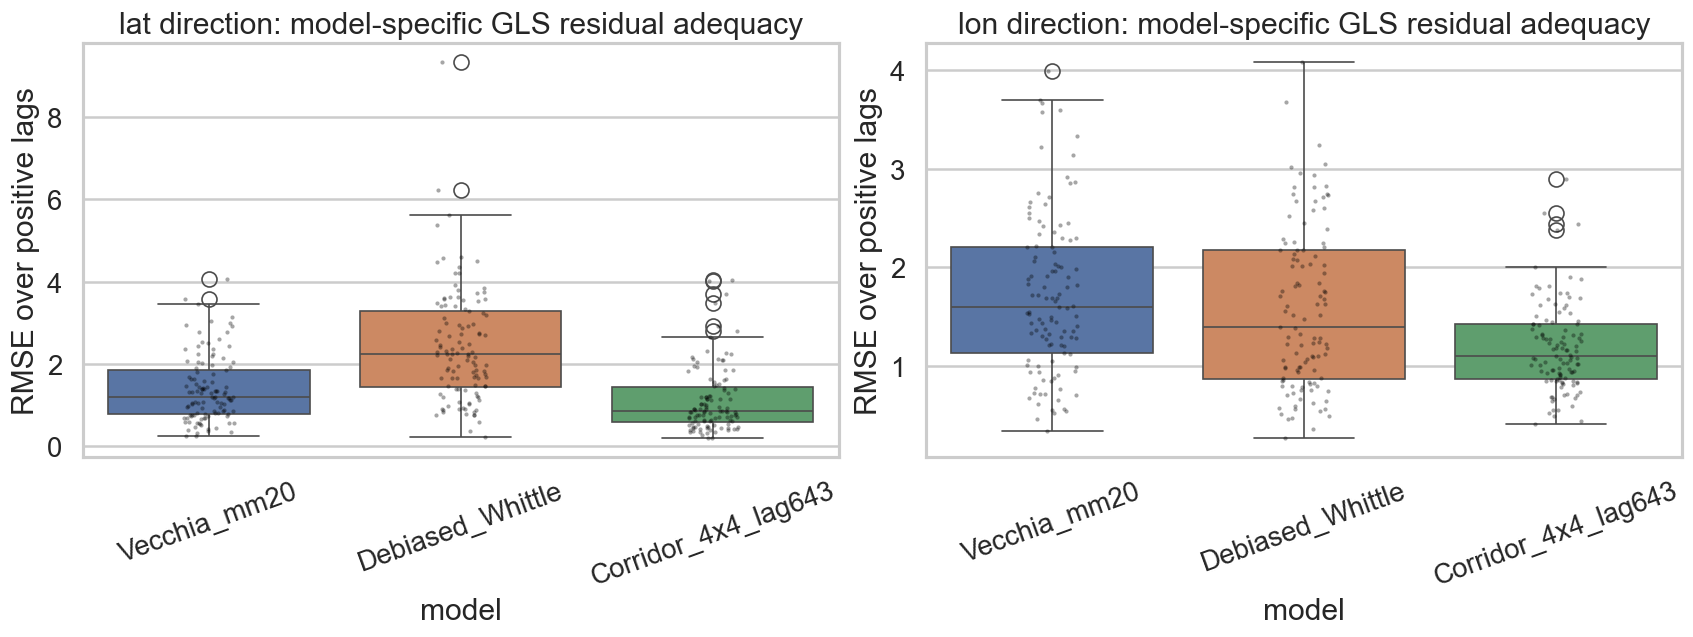

In [8]:
# Compact model-specific GLS residual adequacy summaries.
summary_by_direction = (
    error_table
    .groupby(['direction', 'model'])
    .agg(n=('rmse', 'size'), rmse_mean=('rmse', 'mean'), rmse_median=('rmse', 'median'), mae_mean=('mae', 'mean'), mae_median=('mae', 'median'), bias_mean=('bias_emp_minus_fit', 'mean'), bias_median=('bias_emp_minus_fit', 'median'))
    .round(4)
    .reset_index()
)
summary_overall = (
    error_table
    .groupby('model')
    .agg(n=('rmse', 'size'), rmse_mean=('rmse', 'mean'), rmse_median=('rmse', 'median'), mae_mean=('mae', 'mean'), mae_median=('mae', 'median'), bias_mean=('bias_emp_minus_fit', 'mean'), bias_median=('bias_emp_minus_fit', 'median'))
    .round(4)
    .reset_index()
)
win_rows = []
for keys, group in error_table.groupby(['year', 'day_num', 'direction']):
    best_idx = group['rmse'].idxmin()
    win_rows.append({'year': keys[0], 'day_num': keys[1], 'direction': keys[2], 'winner': error_table.loc[best_idx, 'model'], 'winning_rmse': error_table.loc[best_idx, 'rmse']})
win_table = pd.DataFrame(win_rows)
win_counts = win_table.groupby(['direction', 'winner']).size().reset_index(name='wins').sort_values(['direction', 'wins'], ascending=[True, False])

summary_by_direction_path = OUTPUT_DIR / 'spatial_semivariogram_residual_gls_raw_model_error_summary_by_direction_2022_2025_07.csv'
summary_overall_path = OUTPUT_DIR / 'spatial_semivariogram_residual_gls_raw_model_error_summary_overall_2022_2025_07.csv'
win_counts_path = OUTPUT_DIR / 'spatial_semivariogram_residual_gls_raw_model_win_counts_2022_2025_07.csv'
summary_by_direction.to_csv(summary_by_direction_path, index=False, float_format='%.4f')
summary_overall.to_csv(summary_overall_path, index=False, float_format='%.4f')
win_counts.to_csv(win_counts_path, index=False)
print(f'Saved {summary_by_direction_path}')
print(f'Saved {summary_overall_path}')
print(f'Saved {win_counts_path}')
display(summary_by_direction)
display(summary_overall)
display(win_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)
for ax, direction in zip(axes, ['lat', 'lon']):
    sub = error_table.loc[error_table['direction'].eq(direction)].copy()
    sns.boxplot(data=sub, x='model', y='rmse', hue='model', dodge=False, ax=ax)
    sns.stripplot(data=sub, x='model', y='rmse', color='black', alpha=0.35, size=2.5, ax=ax)
    if ax.legend_:
        ax.legend_.remove()
    ax.set_title(f'{direction} direction: model-specific GLS residual adequacy')
    ax.set_xlabel('model')
    ax.set_ylabel('RMSE over positive lags')
    ax.tick_params(axis='x', rotation=20)
summary_plot = OUTPUT_DIR / 'spatial_semivariogram_residual_gls_raw_model_error_boxplot_2022_2025_07.png'
fig.savefig(summary_plot, bbox_inches='tight')
print(f'Saved {summary_plot}')
plt.show()


## Notes

- This is diagnostic 2: model-specific residual adequacy. Each model's own fitted covariance parameters define the GLS weights used to estimate the daily mean field.
- Full exact GLS over all grid-time observations would require a roughly 145k by 145k covariance matrix per day and is not computationally feasible here. This notebook uses a regular anchor subset with strides `ANCHOR_LAT_STRIDE = 10`, `ANCHOR_LON_STRIDE = 10` for feasible GLS beta estimation, then applies that mean estimate to the full grid.
- The mean model is `ColumnAmountO3 ~ hour fixed effects + latitude + longitude`.
- `NORMALIZE_EMPIRICAL = False`.
- For the normalized notebook, hourly empirical GLS residual semivariograms are divided by the corresponding hourly residual sample variance; fitted model curves are divided by `sigma + nugget`.
- The fitted curves are `t=0` spatial semivariograms, so advection does not enter the plotted t=0 spatial curve. Advection does enter the GLS covariance weights through the model's space-time covariance.
- Zero spatial lag is intentionally excluded. Curves begin at latitude `0.044` and longitude `0.063` degrees, leaving the origin-to-first-lag region blank.
- Numeric CSV outputs are rounded to 4 decimal places.
